In [1]:
## Libraries, modules
import os
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import numpy as np
import scipy.signal as signal
import cv2
from skimage.feature import peak_local_max
from seq_utils import select_win, spec_bandpass, meas_time_freq, signals2list, blank_spectrogram, remove_short_detections, get_tone_segments, find_tone_signals, translate_tones, sig_length, compute_length_metric, validate_list


## Recording file
dir_path = "./D_signal_sequences/"
rec_filename = "231_40300.187_seq.flac"
seq_name = int(rec_filename.split("_")[0])

## FFT Parameters
win_type = "Taylor"
win_size = 2400  # Window size, 1000 to 4000 are ideal
overlap = 80 # Overlap %

# Determine other parameters and initialize FFT
fs = 48000  # Your sampling frequency
hop_size = int(win_size*(1-overlap/100)) # Step/hop size
FFT_sample_T = win_size/fs*(1-overlap/100) # FFT samples duration in s (this is not actual resolution)
if (win_type == "Hann"):
    win = signal.windows.hann(win_size) # Hann window
elif (win_type == "Taylor"):
    win = signal.windows.taylor(win_size, nbar=3, sll=25, norm=True) # Taylor window with parameters: nbar (2), sidelobe suppression level (-25)
elif (win_type == "Rect"):
    win = signal.windows.boxcar(win_size) # Rectangular window
elif (win_type == "Hamming"):
    win = signal.windows.hamming(win_size) # Rectangular window
SFT = signal.ShortTimeFFT(win, hop=hop_size, fs=fs) # Initialize ShortTimeFFT

In [2]:
## Signal samples used for template matching
signal_templates = {
    'X': np.genfromtxt('signal_samples/EOL_avg2_48k-2400-80-Taylor.csv', delimiter=',').astype(np.float32),
    'G': np.genfromtxt('signal_samples/G_avg2_48k-2400-80-Taylor.csv', delimiter=',').astype(np.float32),
    'F': np.genfromtxt('signal_samples/F_avg2_48k-2400-80-Taylor.csv', delimiter=',').astype(np.float32),
    'E': np.genfromtxt('signal_samples/E_avg2_48k-2400-80-Taylor.csv', delimiter=',').astype(np.float32),
    'D': np.genfromtxt('signal_samples/D_avg2_48k-2400-80-Taylor.csv', delimiter=',').astype(np.float32),
}

In [3]:
## Read full audio recording
audio_rec, fs = sf.read(dir_path+rec_filename)
data = audio_rec[:,0] + audio_rec[:,1] # Summing the two doesn't improve SNR, but doesn't hurt either.

## Initialize list of detected signals
signals_detected = []

In [4]:
## Generate Spectrogram (2D FFT)
Sx2 = SFT.spectrogram(data) # Compute the spectrogram (absolute square of STFT)
Sx2[Sx2 == 0] = 1e-10 #np.min(Sx2[np.nonzero(Sx2)]) # Substitute zeros with the minimum non-zero value to avoid log(0)
Sx2_dB = 10 * np.log10(Sx2) # Convert spectrogram to dB
t_min, t_max, f_min, f_max = SFT.extent(len(audio_rec), center_bins=True) # Get frequency and time boundaries
f_bins, t_bins = Sx2.shape # Get the number of frequency and time bins
time_axis = np.linspace(t_min, t_max, t_bins)
freq_axis = np.linspace(f_min, f_max, f_bins)

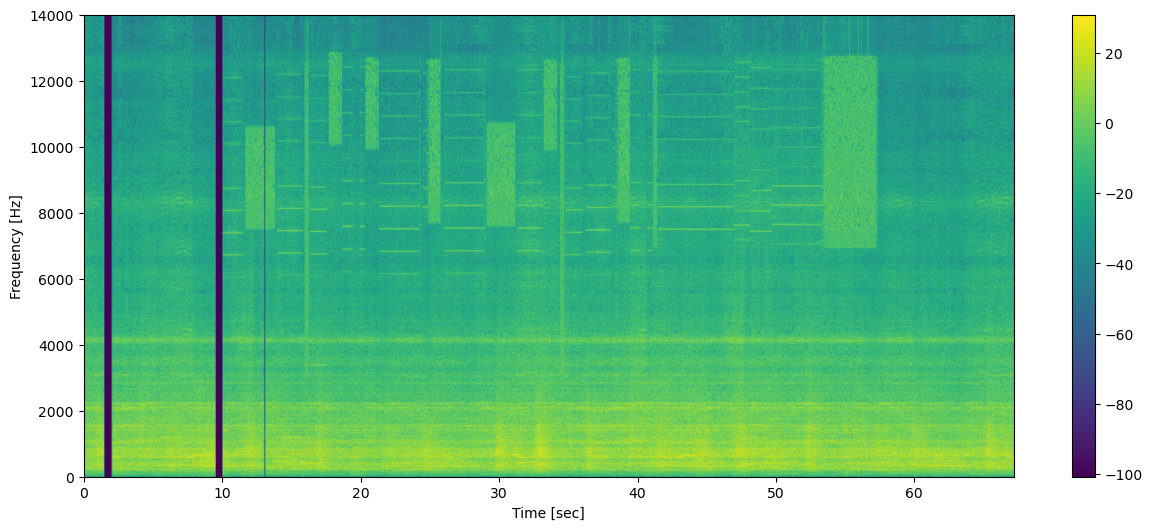

In [5]:
## Crop spectrogram to avoid high frequency aliased signals
f_low = 0
f_high = 14000
recording_crop = spec_bandpass(Sx2_dB, f_max, f_bins, f_low, f_high).astype(np.float32) # Apply bandpass

# Plot the modified spectrogram
plt.figure(figsize=(15,6))
plt.imshow(recording_crop, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

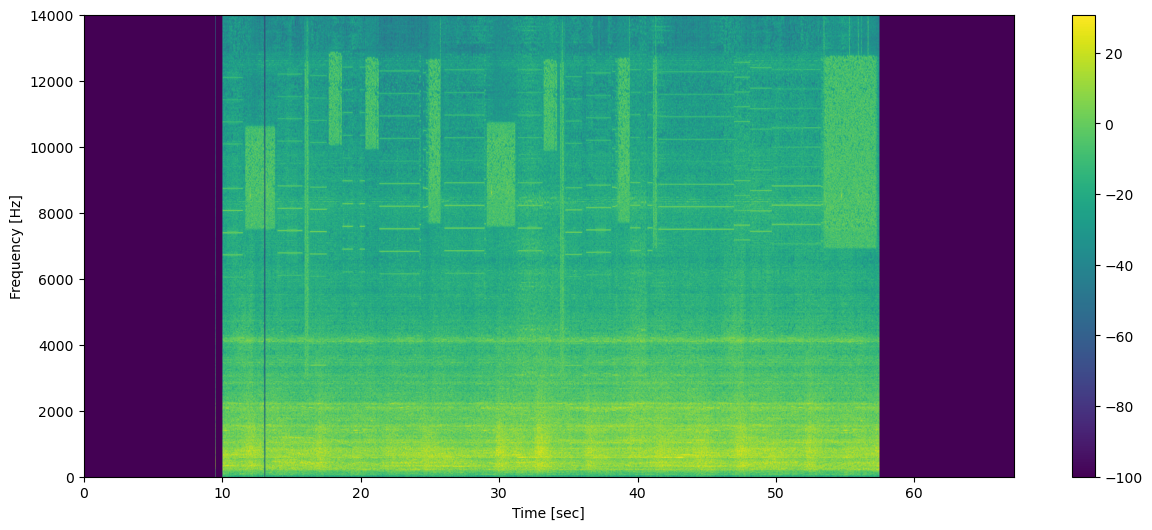

In [6]:
## Blank first 9.5 s and last 9.5 s, they shouldn't contain any signal
recording_crop[:, 0:int(9.5/FFT_sample_T)] = -100 #np.min(recording_crop)
recording_crop[:, -int(9.8/FFT_sample_T):] = -100 #np.min(recording_crop)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.imshow(recording_crop, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

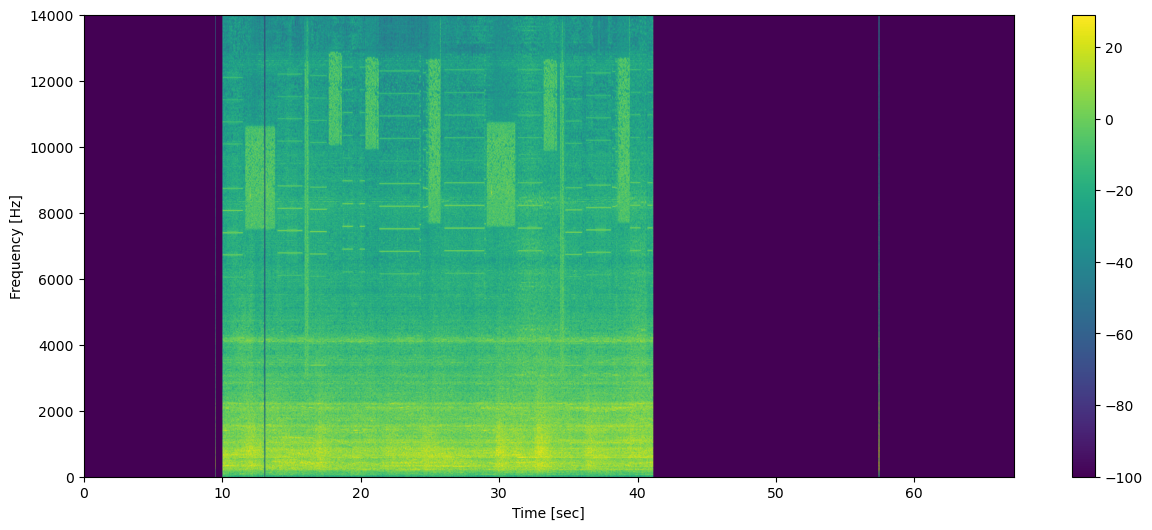

In [7]:
## Detect EOL signal
# Time corrections
t_start_corr = 16.18-3.90 # Correction to signal start time (s)
t_end_corr = 0.1 # Correction to signal end time (s)

# Signal detection
signal = signal_templates['X'] # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.52) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(local_maxima, time_axis, freq_axis) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("X", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_EOL = blank_spectrogram(recording_crop, local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_EOL, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

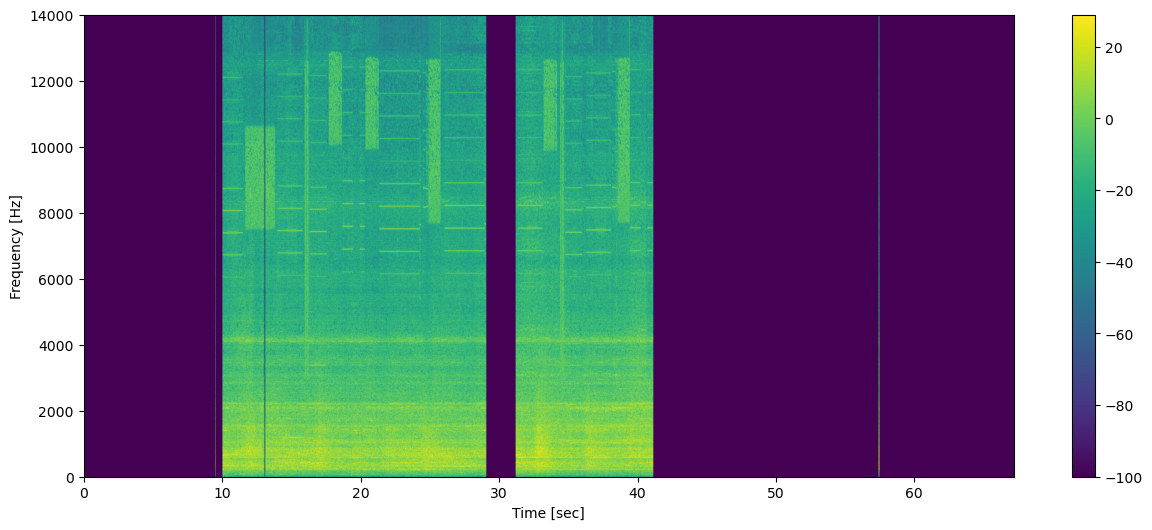

In [8]:
## Detect G signal
# Time corrections
t_start_corr = 0 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = signal_templates['G'] # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_EOL, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.45) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(local_maxima, time_axis, freq_axis) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("G", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_G = blank_spectrogram(recording_crop_blank_EOL, local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_G, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

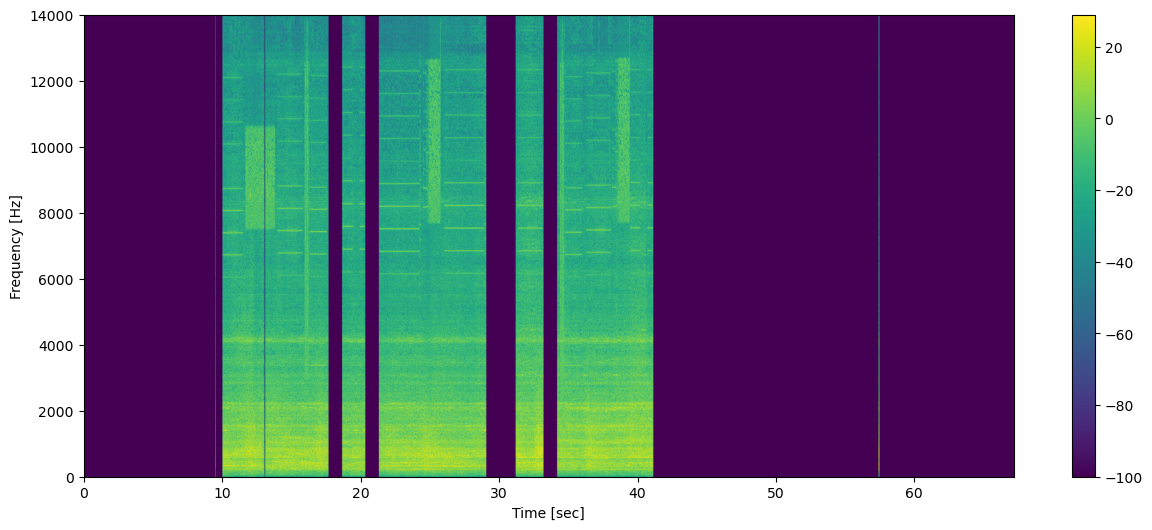

In [9]:
## Detect F signal
# Time corrections
t_start_corr = 0 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = signal_templates['F'] # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_G, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.42) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(local_maxima, time_axis, freq_axis) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("F", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_F = blank_spectrogram(recording_crop_blank_G, local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_F, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

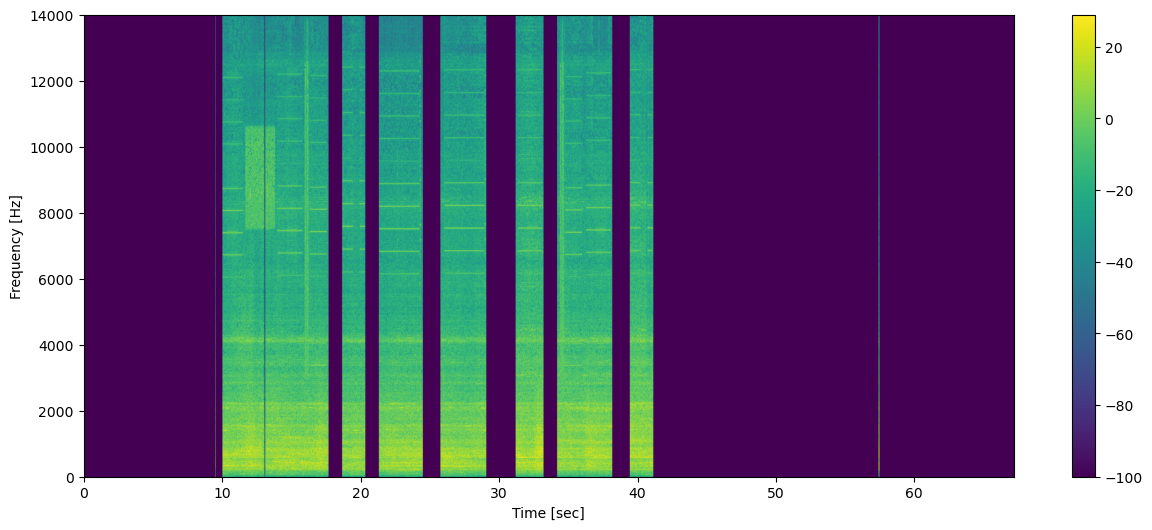

In [10]:
## Detect E signal
# Time corrections
t_start_corr = 1.27-0.89 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = signal_templates['E'] # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_F, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.48) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(local_maxima, time_axis, freq_axis) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("E", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
recording_crop_blank_E = blank_spectrogram(recording_crop_blank_F, local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_E, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

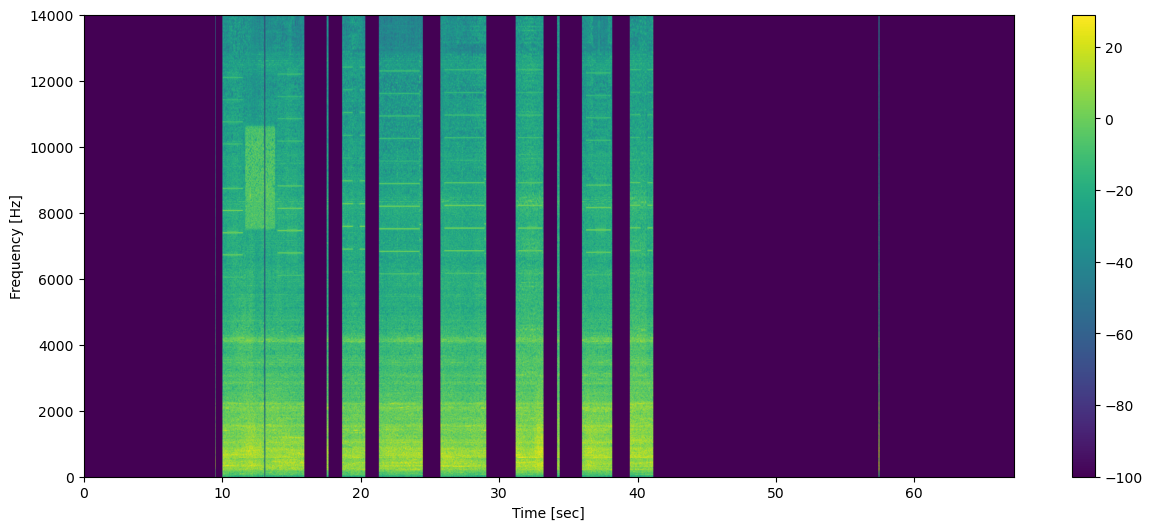

In [11]:
## Detect D signal
# Time corrections
t_start_corr = 1.27-0.89 # Correction to signal start time (s)
t_end_corr = 0 # Correction to signal end time (s)

# Signal detection
signal = signal_templates['D'] # Load signal
correlation_opencv = cv2.matchTemplate(recording_crop_blank_E, signal, cv2.TM_CCOEFF_NORMED) # Signal correlation search based on OpenCV match template
local_maxima = peak_local_max(correlation_opencv, min_distance=10, threshold_abs=0.45) # Find local maxima locations
detected_times, detected_freqs = meas_time_freq(local_maxima, time_axis, freq_axis) # Convert the local maxima indices to time and frequency values
correl_values = correlation_opencv[local_maxima[:, 0], local_maxima[:, 1]] # Extract correlation values
signals_detected = signals2list("D", signals_detected, detected_times-t_start_corr, detected_freqs, correl_values) # Add to list of detected signals

# Blank spectrogram
t_start_corr = 0 # Correction to signal start time (s)
t_end_corr = 1.61-0.31 # Correction to signal end time (s)
recording_crop_blank_D = blank_spectrogram(recording_crop_blank_E, local_maxima, t_start_corr, t_end_corr, signal, t_bins, FFT_sample_T)

# Plot the blanked spectrogram
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_D, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

In [12]:
## Measure background noise level
noise = spec_bandpass(Sx2_dB, f_max, f_bins, 6300, 6700) # Extract noise band
noise_mean = np.mean(noise) # Noise mean level
noise_std = np.std(noise) # Noise standard deviation

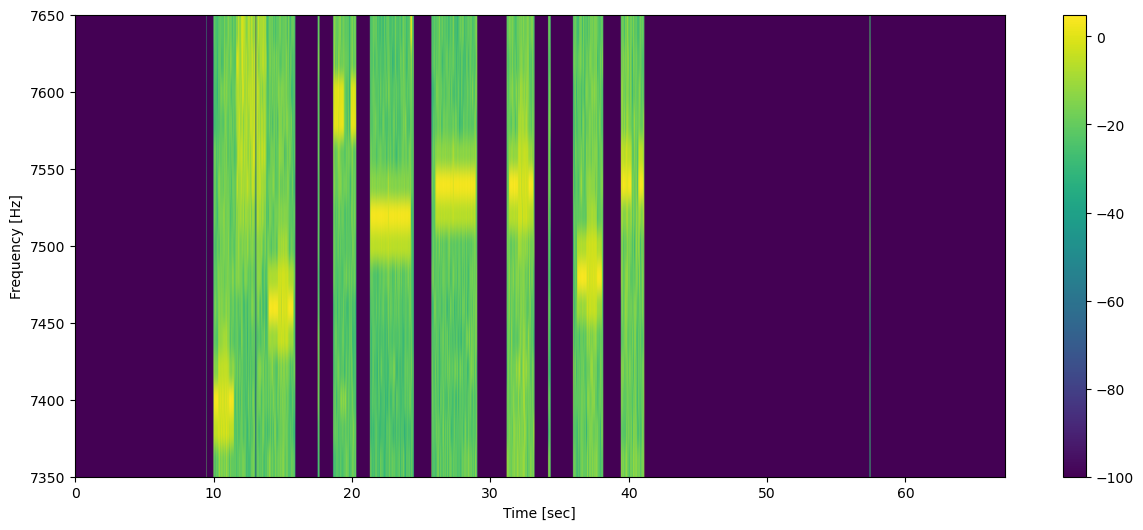

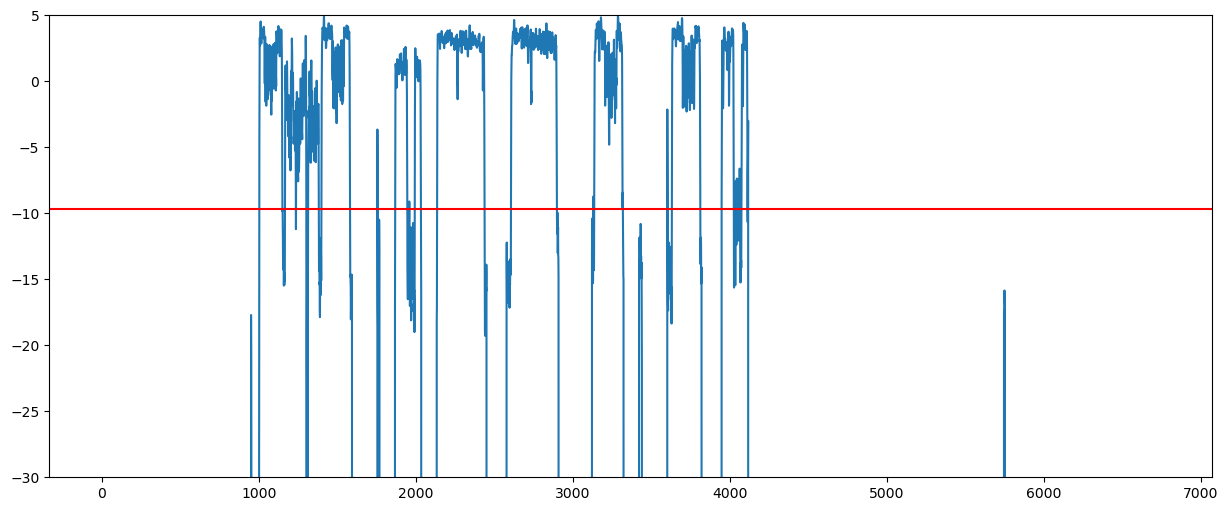

In [13]:
## Measure signal level in strong "tone" band
f_low = 7350 #6650
f_high = 7650 #6950
sig_bandpass = spec_bandpass(recording_crop_blank_D, f_max, f_bins, f_low, f_high) # Apply bandpass
sig_level = np.max(sig_bandpass, axis=0) # Peak values for each time sample
peak_mean = np.mean(sig_level[sig_level > (np.max(sig_level) - 6)]) # Calculate mean of peak values
peak_std = np.std(sig_level[sig_level > (np.max(sig_level) - 6)]) # Calculate std of peak values

# Threshold
sig_max = np.max(sig_level)
threshold = peak_mean - peak_std*2.5 - noise_std*0.75 # Threshold level to detect a signal

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(sig_bandpass, origin='lower', aspect='auto', extent=[t_min, t_max, f_low, f_high])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

plt.figure(figsize=(15,6))
plt.plot(sig_level)
plt.axhline(y = threshold, color = 'r', linestyle = '-')
plt.ylim(-30, 5)
plt.show()

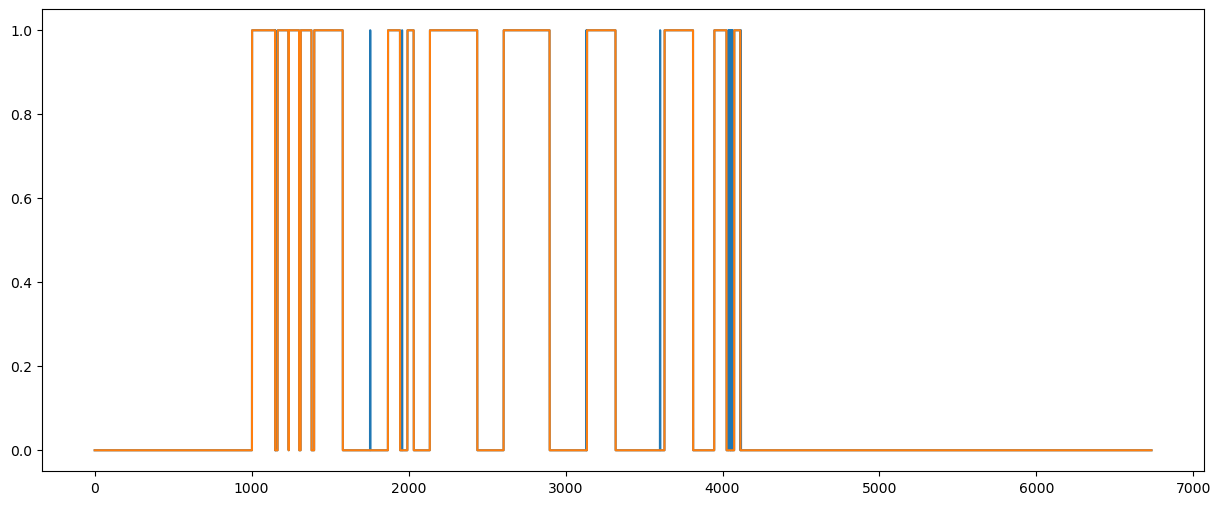

In [14]:
## Create "detection" array
above_threshold = (sig_level > threshold).astype(int) # Array of detections (1) and non-detections (0)
min_ones = int(0.26/FFT_sample_T) # 0.26 seconds, = 0.67 * 0.38 s (the shortest portion of signal C)
sig_detected = remove_short_detections(above_threshold, min_ones)

plt.figure(figsize=(15,6))
plt.plot(above_threshold)
plt.plot(sig_detected)
plt.show()

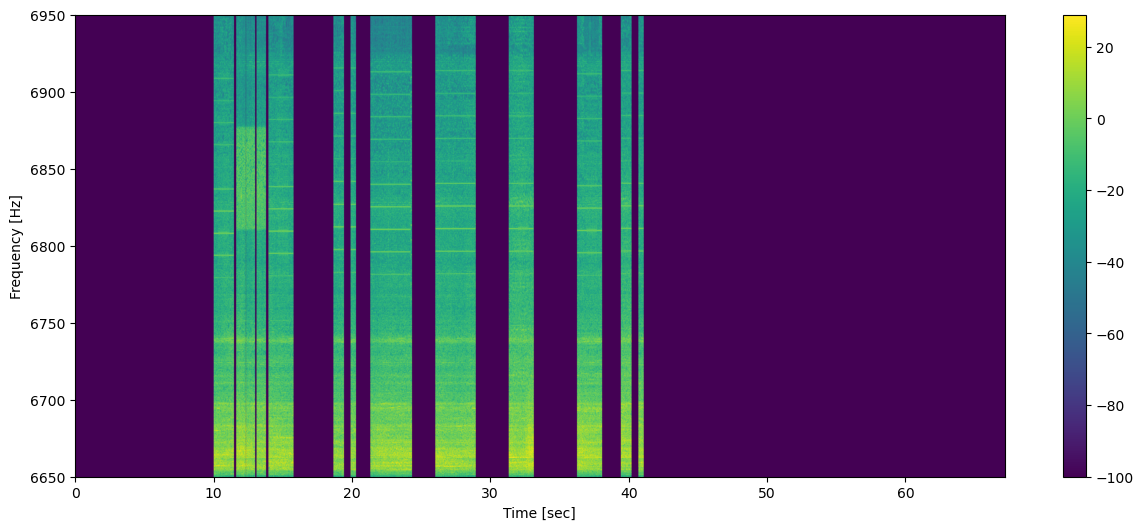

In [15]:
## Blanking of noise sections based on previous detections, then bandpass to low frequency strong tone.
# Cropping based on sig_detected, applied to the original cropped spectrogram
#recording_crop_blank_tones = recording_crop.copy()
recording_crop_blank_D[:, np.where(sig_detected == 0)[0]] = np.min(recording_crop)

# First bandpass filter (wide)
f_low_1 = 6650
f_high_1 = 6950
recording_crop_blank_tones_bp1 = spec_bandpass(recording_crop_blank_D, f_max, f_bins, f_low_1, f_high_1)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_D, origin='lower', aspect='auto', extent=[t_min, t_max, f_low_1, f_high_1])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

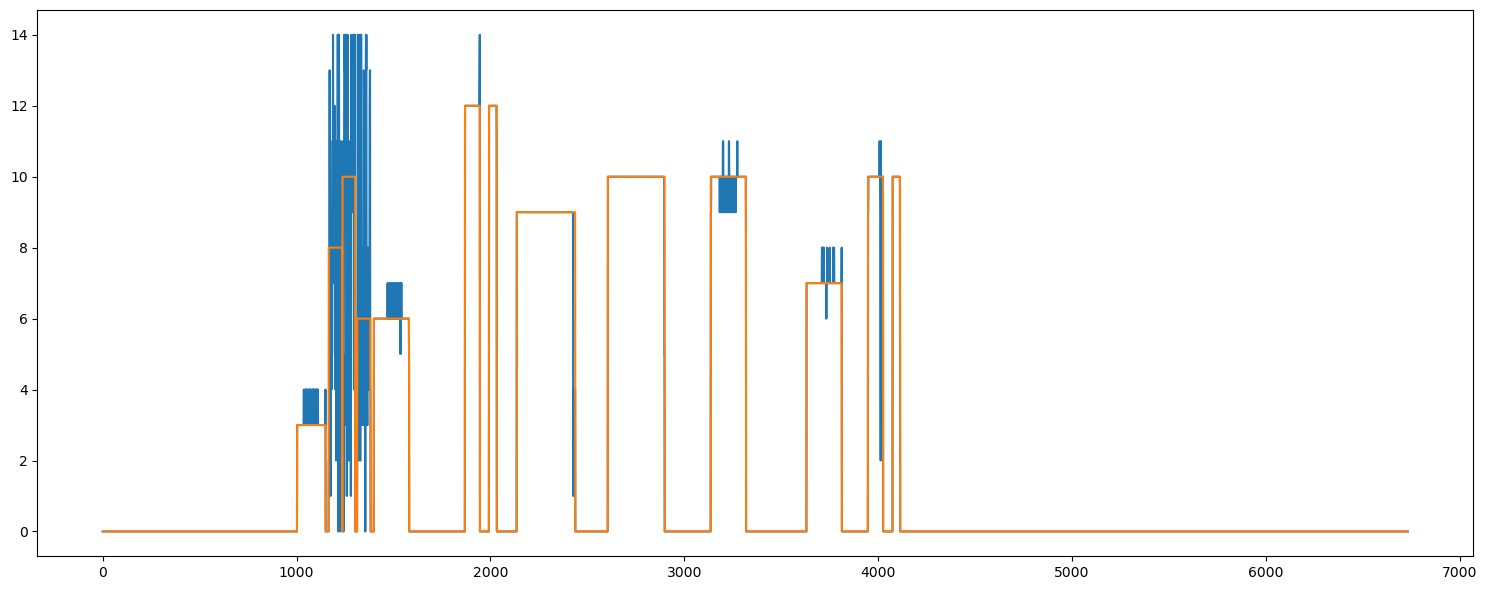

In [16]:
## Find local maxima for each tone (frequency sample), 1st pass
# Local maxima, this is often noisy
tones_local_max = np.argmax(recording_crop_blank_tones_bp1, axis=0)

# Find indices at the end tone segments
det_idx = np.where(sig_detected == 1)[0] # Find the indices where a tone is s detected
tone_segm_boundaries = np.where(np.diff(det_idx) > 1)[0] + 1 # Find the boundaries where the difference is greater than 1
tone_segm_boundaries = np.concatenate(([0], tone_segm_boundaries, [len(det_idx)])) # Add the first and last index to define the tone segments

# Calculate the median of tones_local_max for each tone segment
medians = np.zeros(len(tone_segm_boundaries) - 1)
for i in range(len(medians)):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    medians[i] = np.median(tones_local_max[segment])

# Initialize an array for tones_local_max_med, add the corresponding median for each segment (this works as a filter)
tones_freq_med = np.copy(tones_local_max)
for i in range(len(medians)):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    tones_freq_med[segment] = medians[i]

# Plot both original and modified (median) tones
plt.figure(figsize=(15,6))
plt.plot(tones_local_max)
plt.plot(tones_freq_med)
plt.tight_layout()
plt.show()

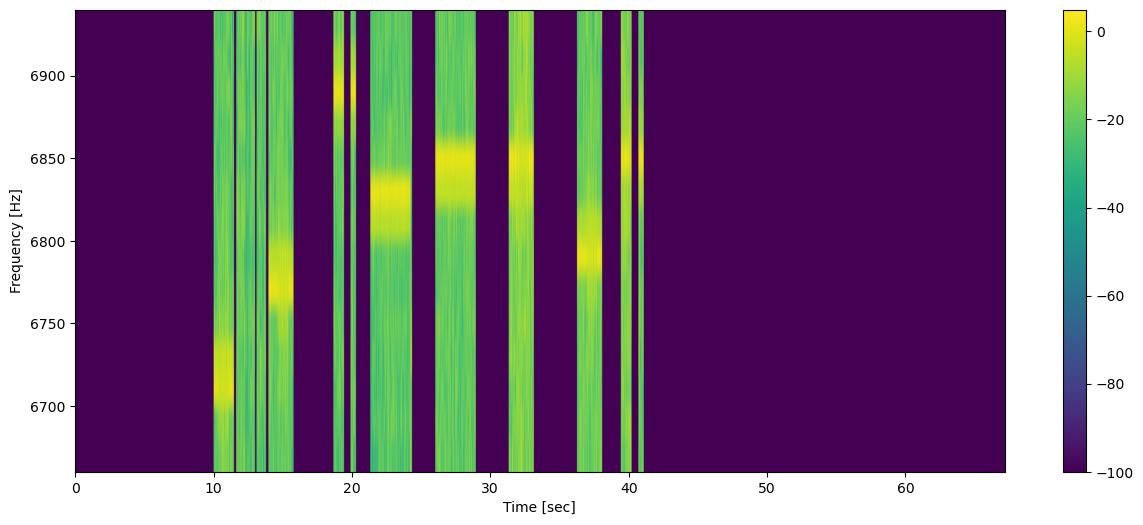

In [17]:
## Determine min/max tone frequencies, then run second bandpass (narrow)
margin = 50 # Frequency margin below and above tones
f_low_2 = np.min(tones_freq_med[tones_freq_med != 0])*fs/win_size + f_low_1 - margin
f_high_2 = np.max(tones_freq_med)*fs/win_size + f_low_1 + margin
recording_crop_blank_tones_bp2 = spec_bandpass(recording_crop_blank_D, f_max, f_bins, f_low_2, f_high_2)

# Plot 'cropped' spectrogram  (in dB)
plt.figure(figsize=(15,6))
plt.imshow(recording_crop_blank_tones_bp2, origin='lower', aspect='auto', extent=[t_min, t_max, f_low_2, f_high_2])
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.show()

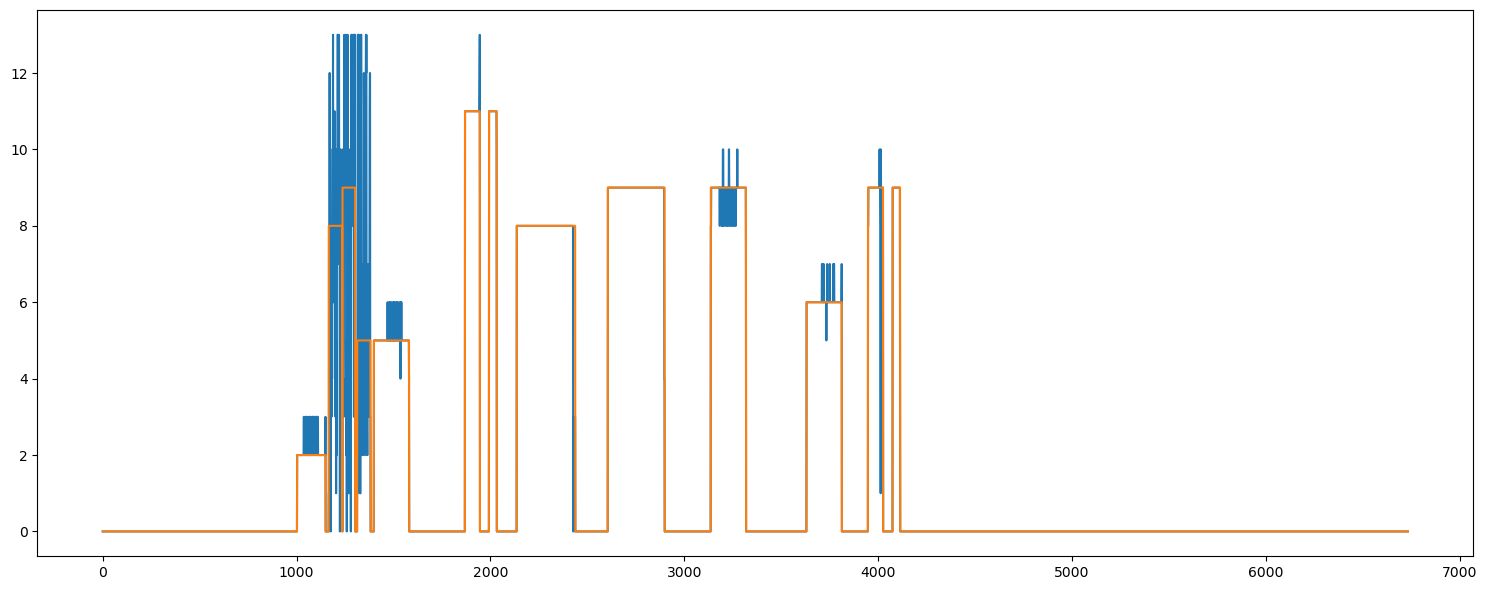

In [18]:
## Find local maxima for each tone (frequency sample), 2nd pass
# Local maxima, this is often noisy
tones_local_max = np.argmax(recording_crop_blank_tones_bp2, axis=0)

# Find indices of tone segments
det_idx = np.where(sig_detected == 1)[0] # Find the indices where a tone is s detected
tone_segm_boundaries = np.where(np.diff(det_idx) > 1)[0] + 1 # Find the boundaries where the difference is greater than 1
tone_segm_boundaries = np.concatenate(([0], tone_segm_boundaries, [len(det_idx)])) # Add the first and last index to define the tone segments

# Calculate the median of tones_local_max for each tone segment
medians = np.zeros(len(tone_segm_boundaries) - 1)
for i in range(len(medians)):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    medians[i] = np.median(tones_local_max[segment])

# Initialize an array for tones_local_max_med, add the corresponding median for each segment (this works as a filter)
tones_freq_med = np.copy(tones_local_max)
for i in range(len(medians)):
    segment = det_idx[tone_segm_boundaries[i]:tone_segm_boundaries[i+1]]
    tones_freq_med[segment] = medians[i]

# Plot both original and modified (median) tones
plt.figure(figsize=(15,6))
plt.plot(tones_local_max)
plt.plot(tones_freq_med)
plt.tight_layout()
plt.show()

In [19]:
## Detect tones
# Find tone signals (as sequences of values above 0)
tone_signals = find_tone_signals(sig_detected, tones_freq_med)

# Print the result with start_idx, end_idx, and median value
for row in tone_signals:
    print(str(row) + " " + str(row[1]-row[0]))

(1003, 1149, 2) 146
(1166, 1235, 8) 69
(1237, 1302, 9) 65
(1313, 1381, 5) 68
(1399, 1580, 5) 181
(1869, 1945, 11) 76
(1993, 2032, 11) 39
(2136, 2437, 8) 301
(2606, 2898, 9) 292
(3137, 3318, 9) 181
(3631, 3812, 6) 181
(3948, 4025, 9) 77
(4075, 4113, 9) 38


In [20]:
# Detect which tones occur
try:
    tones_list = translate_tones(tone_signals, FFT_sample_T, seq_name)
except ValueError as e:
    print(f"Error: {e}")

# Convert to time and frequency values
tone_type = np.array(tones_list)[:, 3]
tone_times = np.array([row[0] for row in tones_list])
tone_freqs = np.array([row[4] for row in tones_list])
detected_times = np.linspace(t_min, t_max, t_bins)[tone_times] # Time values from indices
detected_freqs = np.linspace(f_min, f_max, f_bins)[tone_freqs] + f_low_2  # Frequency values from indices, corrected for previous bandpass

# Calculate length metric
length_metric = np.zeros(len(tones_list))
length_samples = np.array([row[2] for row in tones_list]) # Length of tones (in # samples), it shouldn't differ much from 'standard' values
for t in range(len(length_samples)):
    if tone_type[t] == "A":
        A_sample_length = int(sig_length('A')/FFT_sample_T)
        length_metric[t] = (1 - ((length_samples[t] - A_sample_length) / A_sample_length))  # Tone A length metric
    if tone_type[t] == "B":
        B_sample_length = int(sig_length('B')/FFT_sample_T)
        length_metric[t] = (1 - ((length_samples[t] - B_sample_length) / B_sample_length))  # Tone B length metric
    if tone_type[t] == "C":
        C_sample_length = int(sig_length('C')/FFT_sample_T)
        length_metric[t] = (1 - ((length_samples[t] - C_sample_length) / C_sample_length))  # Tone C length metric

# Add to list of detected signals
for i in range(len(detected_times)):
    signals_detected.append([
        tone_type[i], # Signal type
        round(detected_times[i], 2), # Time rounded to 2 decimal places
        int(detected_freqs[i]), # Frequency as an integer
        round(length_metric[i], 2) # Length metric as an integer
    ])

Seq 231 Warning: Split B signal detected at t = 10.03s
Seq 231 Warning: Double split B signal detected at t = 12.37s


In [21]:
## Final signal sorting and checks
# Sort list based on time
signals_detected = sorted(signals_detected[:], key=lambda x: x[1])

# Sequence validation
def validate_list(signals_detected):
    # Check 1: EOL occurs only once
    x_count = sum(1 for item in signals_detected if item[0] == 'X')
    if x_count != 1:
        print("Error: EOL signal appears more than once!")
        return True
    # Check 2: EOL occurs at the end
    if  signals_detected[-1][0] != 'X':
        print("Error: EOL signal found before the end of the sequence!")
        return True
    # Check 3: No consecutive signals of the same type
    for i in range(1, len(signals_detected)):
        if signals_detected[i][0] == signals_detected[i - 1][0]:
            print(f"Error: Consecutive signal '{signals_detected[i][0]}' found at positions {i-1} and {i}.")
            return True
    # Check 4: No excessive gap between signals, set at 90% of 0.98 s (the shortest signal)
    for i in range(1, len(signals_detected)):
        t_gap = signals_detected[i][1] - signals_detected[i-1][1] - sig_length(signals_detected[i-1][0])
        if t_gap > 0.98*0.9:
            t_gap_start = signals_detected[i-1][1] + sig_length(signals_detected[i-1][0])
            print(f"Error: Likely undetected signal at {i} {t_gap_start} s for {t_gap} s")
            return True            
    return True

if validate_list(signals_detected):
    for row in signals_detected:
        print(row)

Error: Consecutive signal 'B' found at positions 0 and 1.
['B', 9.99, 6690, 0.7]
['B', 12.32, 6830, 0.08]
['D', 15.5, 7516, 0.82]
['F', 17.63, 10018, 0.78]
['C', 18.63, 6870, 1.0]
['F', 20.29, 9878, 0.87]
['A', 21.29, 6810, 1.0]
['E', 24.44, 7596, 0.67]
['A', 25.98, 6830, 1.03]
['G', 29.02, 7556, 0.61]
['B', 31.28, 6830, 0.99]
['F', 33.15, 9818, 0.88]
['D', 33.94, 7476, 0.75]
['B', 36.21, 6770, 0.99]
['E', 38.11, 7616, 0.69]
['C', 39.38, 6830, 0.99]
['X', 41.05, 6875, 0.89]
